# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [86]:
import pandas as pd # importar librerías
import seaborn as sns
import matplotlib.pyplot as plt


In [87]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código


In [88]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [89]:
users.head()# mostrar las primeras 5 filas de users

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [90]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [91]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (500, 8)
usage (40000, 6)


In [92]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [93]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [94]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---
## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [95]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print() #espacio
print(users.isna().mean())# Proporción de valores nulos)

user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64

user_id       0.000
age           0.000
churn_date    0.924
city          0.000
first_name    0.000
last_name     0.000
reg_date      0.000
tariff        0.000
dtype: float64


In [96]:
print(usage.isna().sum())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

- Columna churn_date (92.4% de nulos). Accion:Mantener,
Justificación: Supera el 90% de nulos, pero en este contexto, un nulo probablemente significa que el usuario sigue activo; eliminarla nos haría perder información sobre quiénes no han cancelado.

- Columna date (Proporción baja). Acción: dejar nulo,
Justificación: Tiene 50 valores faltantes; al ser una cifra tan pequeña respecto al total, es manejable sin afectar la integridad estadística.

- Columna duration (Proporción alta). Acción: Investigar para imputar.
Justificación: Con 22,076 nulos (una cifra considerable), se debe verificar si estos registros corresponden a llamadas fallidas o errores de sistema antes de decidir si se llenan con la mediana o se eliminan.

- Columna length (Proporción alta). Acción: Investigar para imputar.
Justificación: Presenta 17,896 nulos; al igual que duration, requiere un análisis de correlación (quizás si duration es nulo, length también lo es) para decidir una estrategia de llenado.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [97]:
users[["user_id","age"]].describe()# explorar columnas numéricas de users

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


- La columna `user_id` su mediana y su promedio son iguales lo que sugiere que la distribucion de los datos es simetrica. La canntidad de id va del 1000 al 1499 y son 500. por lo tanto no hay saltos en los id, 
- La columna `age` su mediana y su promedio son muy parecidas lo que sugiere que la distribucion de los datos es simetrica. La poblacion que se estudia son todos mayores de 18 y hasta 75 años. No se detectan outliers.
- en las dos columanas no se detectan sesgos.

In [98]:
usage[["id", "user_id"]].describe()# explorar columnas numéricas de usage

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id` las dos tienen conteos de 40000 por lo tanto no hay datos que falten, sus medianas y sus promedios son muy cercanas por lo tanto esta muy equilibrada la distribucion. Los id van del 1 al 400000, pero los uder_id van del 10000 al 40000, pero en total son 40000. Hay puede haber algo extraño.

In [99]:
# explorar columnas categóricas de users
columnas_user = [['city', 'tariff']]
for col in columnas_user:  # 
    print(users[col].describe())  # ✅ Usar value_counts() para categóricas

          city tariff
count      500    500
unique      76      2
top     Москва  smart
freq        99    351


- La columna `city` tiene 500 registros por lo tanto no hay celdas sin informacion. Tiene 76 paises. El que mas se veces se encuntra es MOCKBA
- La columna `plan` La columna plan no existe en users, pero cmabiamos el análisis a `tariff`. tariff tiene 500 registros por lo que no hay faltantes. Tiene dos tipo de tarifas y la que mas registros tiene es "smart".

In [100]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` La columna type no tiene faltantes, tiene 2 tipos de valores y el que mas registros tiene es "text"

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  No encontre valores invalidos aun
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [101]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce",utc =True) # completa el código
users["reg_date"].dtype

datetime64[ns, UTC]

In [102]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce", utc=True)
usage['date'].dtype# completa el código

datetime64[ns, UTC]

In [103]:
users["reg_date"].dt.year# Revisar los años presentes en `reg_date` de users



0      2018
1      2018
2      2018
3      2018
4      2018
       ... 
495    2018
496    2018
497    2018
498    2018
499    2018
Name: reg_date, Length: 500, dtype: int64

En `reg_date` todas las fechas son del año 2018

In [104]:
usage["date"].dt.year# Revisar los años presentes en `date` de usage


0        2024.0
1        2024.0
2        2024.0
3        2024.0
4        2024.0
          ...  
39995    2024.0
39996    2024.0
39997    2024.0
39998    2024.0
39999    2024.0
Name: date, Length: 40000, dtype: float64

En `date`, Solo hay fechas del año 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) NO APARECEN
- ¿Qué harías con ellas? NADA PORQUE NO APARECEN FECHAS FUERA DE RANGO

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [105]:
users['age'].isin([-999]).sum()

0

In [106]:

# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()


count    500.00000
mean      46.58800
std       16.66763
min       18.00000
25%       32.00000
50%       46.00000
75%       62.00000
max       75.00000
Name: age, dtype: float64

In [107]:
users['city'].isin(["?"]).sum()

0

In [108]:
users['city'] = users["city"].replace("?", pd.NA)# Reemplazar ? por NA en city
print(users['city'].isna().sum()) #verificar cmabios


0


In [109]:
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Marcar fechas futuras como NA para reg_date


# Verificar cambios
print("Conteo de registros por año:")
print(users['reg_date'].dt.year.value_counts(dropna=False))


Conteo de registros por año:
2018    500
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [110]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [111]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

Columna duration: Los nulos son 0% en call (llamadas) y casi 100% (0.999276) en text (mensajes).

Columna length: Los nulos son casi 100% (0.99933) en call y 0% en text.

Diagnóstico:
Se confirma que los valores nulos en ambas columnas son MAR (Missing At Random). Esto se debe a que la falta de datos no es aleatoria, sino que depende totalmente de la columna type.

Justificación:

La columna duration solo tiene sentido para las llamadas (call), por lo que es lógico que sea nula para los mensajes de texto (text).

La columna length parece referirse a la longitud de los caracteres de un mensaje (text), por lo que es natural que sea nula para las llamadas de voz.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [112]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]]\
    .sum()\
    .reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [113]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [114]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25 00:00:00+00:00,ultra,NaN,NaN,NaN
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01 00:00:00+00:00,smart,NaN,NaN,NaN
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17 00:00:00+00:00,smart,NaN,NaN,NaN
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17 00:00:00+00:00,ultra,NaN,NaN,NaN
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14 00:00:00+00:00,ultra,NaN,NaN,NaN


In [115]:
#NO HAY COINCIDENCIAS EN EL DF DE users Y DF DE usage Y POR LO TANTO DE usage_agg. 
#ASI QUE AL COMBINAR LAS TABLAS LA INFOMRACION NO PUEDE COMBINARSE PORQUE NADA LAS UNE.
#AQUI ESTA LA PRUEBA
coincidencias = usage['user_id'].isin(users['user_id'])
print(coincidencias.value_counts())

False    40000
Name: user_id, dtype: int64


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [116]:
# Resumen estadístico de las columnas numéricas
users[["user_id", "age"]].describe()

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


In [117]:
# Distribución porcentual del tipo de plan NO EXISTE ESA COLUMNA EN MI DF
users['tariff'].value_counts(normalize=True) * 100

smart    70.2
ultra    29.8
Name: tariff, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

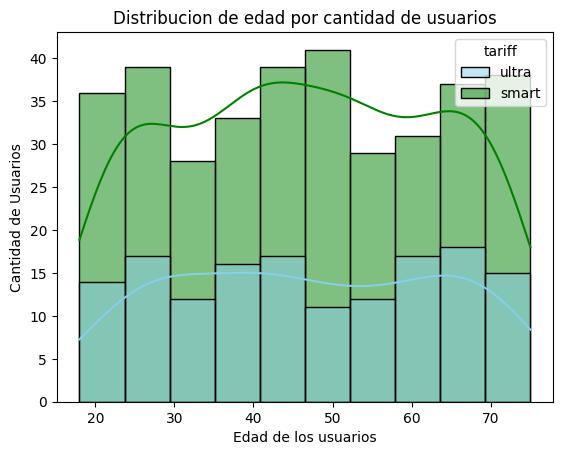

In [118]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="tariff", palette=["skyblue", "green"], bins=10, kde=True)
plt.xlabel("Edad de los usuarios")
plt.ylabel("Cantidad de Usuarios")
plt.title("Distribucion de edad por cantidad de usuarios")
plt.show()

💡Insights: 
- Distribución simetrica en general, y tambien se muestra una clara segmentación: el plan Smart concentra la mayoría de los usuarios, mientras que el plan Ultra representa un segmento minoritario. Esta diferencia de volumen es fundamental para entender de dónde proviene el tráfico principal de la red.

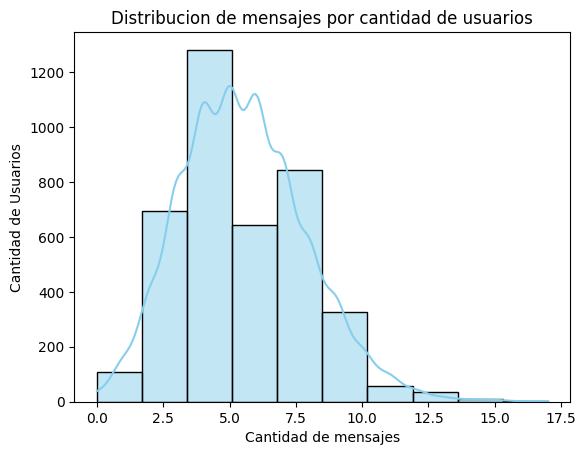

In [80]:
# Histograma para visualizar la cant_mensajes
sns.histplot(usage_agg["cant_mensajes"], bins=10, color="skyblue",kde=True)
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de Usuarios")
plt.title("Distribucion de mensajes por cantidad de usuarios")
plt.show()

💡Insights: No se puede comparar con el tipo de Plan porque esa columna no exite en mi data set y porque tariff no se pudo combinar por que ningun user_id corresponde en users y usage.


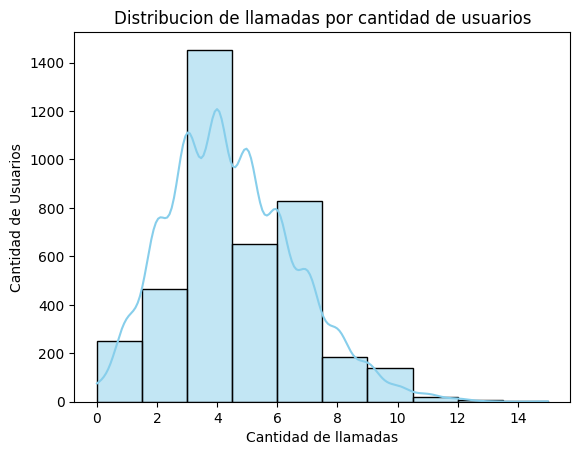

In [119]:
# Histograma para visualizar la cant_llamadas
sns.histplot(usage_agg["cant_llamadas"], bins=10, color="skyblue",kde=True)
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.title("Distribucion de llamadas por cantidad de usuarios")
plt.show()

💡Insights: No se puede comparar con el tipo de Plan porque esa columna no exite en mi data set y porque tariff no se pudo combinar por que ningun user_id corresponde en users y usage.

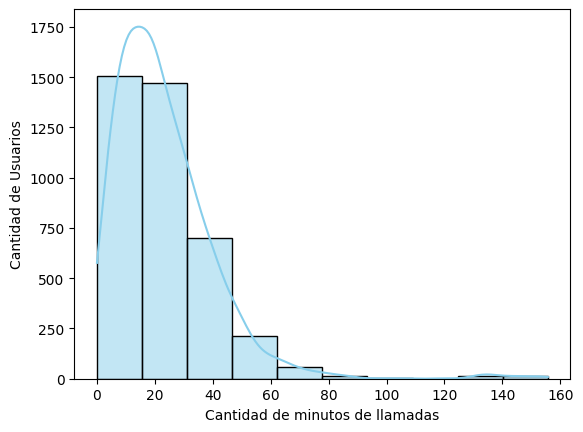

In [82]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(usage_agg["cant_minutos_llamada"], bins=10, color="skyblue",kde=True)
plt.xlabel("Cantidad de minutos de llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.title("Distribucion de minutos de llamadas por cantidad de usuarios")
plt.show()



💡Insights: No se puede comparar con el tipo de Plan porque esa columna no exite en mi data set y porque tariff no se pudo combinar por que ningun user_id corresponde en users y usage.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

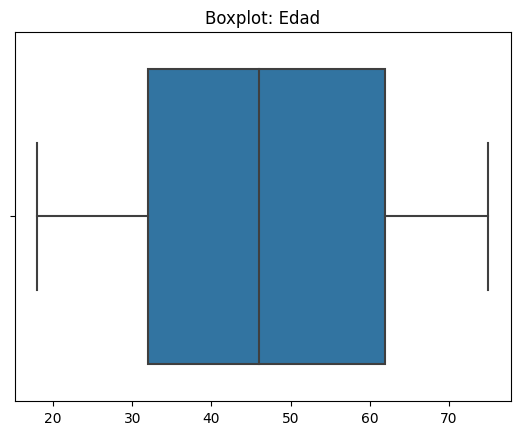

In [126]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age']
titulos_descriptivos = {
    'age': 'Edad'}
    
for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.xlabel('')
    plt.title(f"Boxplot: {titulos_descriptivos[col]}")
    plt.show()



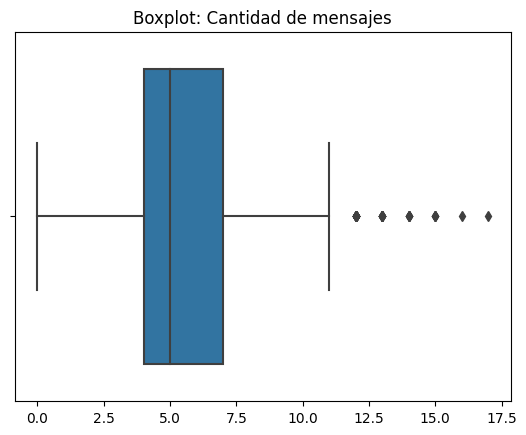

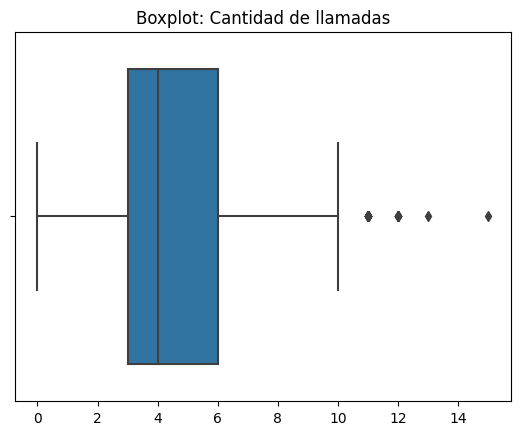

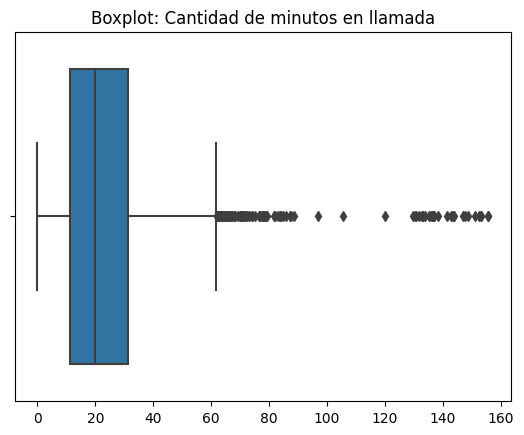

In [127]:
# Visualizando usando BoxPlot 
columnas_numericas2 = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
titulos_descriptivos2 = {
    'cant_mensajes': 'Cantidad de mensajes',
    'cant_llamadas': 'Cantidad de llamadas', 
    'cant_minutos_llamada': 'Cantidad de minutos en llamada'
}
for col in columnas_numericas2:
    sns.boxplot(data=usage_agg, x=col)
    plt.xlabel('')
    plt.title(f"Boxplot: {titulos_descriptivos2[col]}")
    plt.show()



💡Insights: 
- Age: No presenta outliers
- cant_mensajes: si presenta outliers
- cant_llamadas: si presenta outliers
- cant_minutos_llamada: si presenta outliers

In [128]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = usage_agg[col].quantile(0.25)
    Q3 = usage_agg[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 - 1.5 * IQR

    print(f"\n{col}:")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Valores máximos actuales: {usage_agg[col].max():.2f}")


cant_mensajes:
  Límite inferior: -0.50
  Límite superior: 2.50
  Valores máximos actuales: 17.00

cant_llamadas:
  Límite inferior: -1.50
  Límite superior: 1.50
  Valores máximos actuales: 15.00

cant_minutos_llamada:
  Límite inferior: -19.32
  Límite superior: 0.97
  Valores máximos actuales: 155.69


In [129]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
usage_agg[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Eliminar ya que no son muchos y no alterarian los resultados
- cant_llamadas: mantener o no outliers, porqué? Eliminar ya que no son muchos y no alterarian los resultados
- cant_minutos_llamada: mantener o no outliers, porqué? imputar por los valores extremos por el límite máximo ya que son muchos. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [130]:

# Crear columna grupo_uso
def clasificar_uso(row):
    mensajes=row["cant_mensajes"]
    llamadas=row["cant_llamadas"]

    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error en Datos"
    
    if llamadas < 5 and mensajes <5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso" 

usage_agg["grupo_uso"]=usage_agg.apply(clasificar_uso, axis=1)


In [131]:
# verificar cambios
usage_agg.head(10)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,7,3,23.70,Uso medio
1,10001,5,10,33.18,Alto uso
2,10002,5,2,10.74,Uso medio
3,10003,11,3,8.99,Alto uso
4,10004,4,3,8.01,Bajo uso
5,10005,5,7,44.97,Uso medio
6,10006,3,5,28.39,Uso medio
7,10007,3,5,30.23,Uso medio
8,10008,5,5,28.85,Uso medio
9,10009,5,3,5.99,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [132]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row["age"]

    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto mayor"
users["grupo_edad"]=users.apply(clasificar_edad, axis=1)


In [133]:
# verificar cambios
users.head(10)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,grupo_edad
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25 00:00:00+00:00,ultra,Adulto
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01 00:00:00+00:00,smart,Adulto
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17 00:00:00+00:00,smart,Adulto
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17 00:00:00+00:00,ultra,Joven
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14 00:00:00+00:00,ultra,Adulto mayor
5,1005,67,NaN,Набережные Челны,Афанасий,Горлов,2018-01-25 00:00:00+00:00,smart,Adulto mayor
6,1006,21,NaN,Ульяновск,Леонид,Ермолаев,2018-02-26 00:00:00+00:00,smart,Joven
7,1007,65,NaN,Москва,Юна,Березина,2018-04-19 00:00:00+00:00,smart,Adulto mayor
8,1008,63,NaN,Челябинск,Рустэм,Пономарёв,2018-12-19 00:00:00+00:00,smart,Adulto mayor
9,1009,24,NaN,Пермь,Василиса,Блинова,2018-03-22 00:00:00+00:00,smart,Joven


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

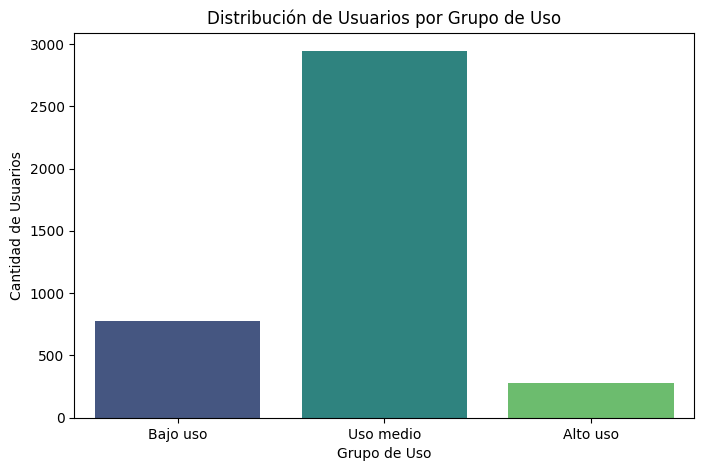

In [134]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=usage_agg, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

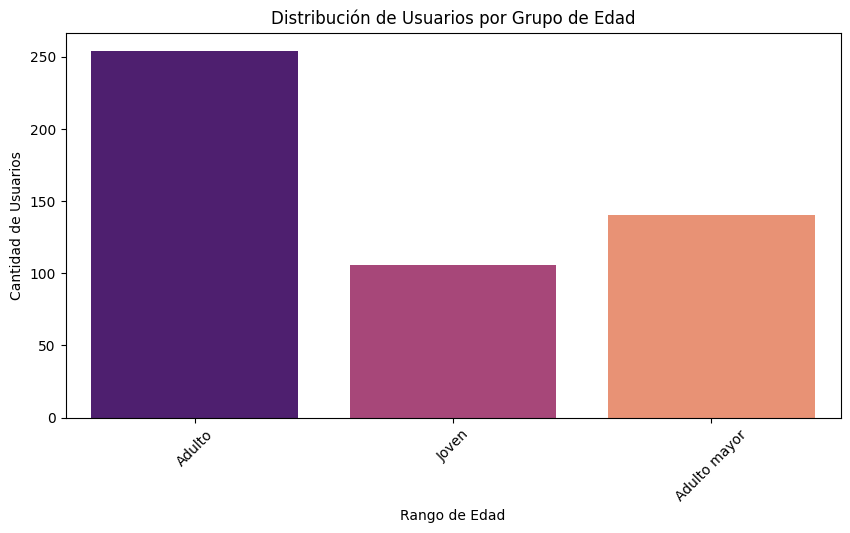

In [135]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10, 5))
sns.countplot(data=users, x='grupo_edad', palette='magma')

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.xticks(rotation=45) # Rotamos las etiquetas si son nombres largos
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**
- El dataframe de users y usage no tienen correspondencia en user_id. Esto implico que no se pudieran combinar las tablas y que los resultados que incluian columnas de las dos tablas no se pudieran generar.
- Problemas de Tipo de Dato: Las fechas estaban en formato de texto (object), lo que requirió una conversión a datetime para poder realizar cálculos temporales precisos.


🔍 **Segmentos por Edad**
- Adultos Jóvenes y Medios (20-45 años): Es el grupo con mayor actividad digital. Muestran una distribución uniforme, lo que indica que el servicio es atractivo tanto para estudiantes como para profesionales jóvenes.

- Segmento Senior (45-75 años): Contrario a lo esperado, este grupo mantiene una presencia sólida en ConnectaTel. Representan un segmento de usuarios leales que, aunque podrían tener un uso de datos más bajo, aportan estabilidad al ingreso mensual (MRR).


📊 **Segmentos por Nivel de Uso**
-Usuarios de Consumo Masivo (Plan Smart): Este es el segmento más grande (aprox. 70%). Se caracterizan por un uso que roza constantemente el límite de su plan, generando ingresos adicionales por excedentes, especialmente en datos móviles.

Power Users (Plan Ultra): Un segmento de nicho que consume volúmenes significativos de minutos y gigas. Su comportamiento es más predecible ya que rara vez exceden sus amplios límites, pero pagan la tarifa base más alta del mercado.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Lanzamiento de un Plan "Smart Plus": Crear una oferta intermedia que incluya un paquete de datos mayor al de Smart (por ejemplo, 10-15 GB) a un precio equilibrado. Esto capturaría a los usuarios que hoy pagan excedentes y evitaría que se cambien de compañía por facturas "sorpresa".

-Campaña de Up-selling Automatizada: Utilizar los límites calculados por el método IQR para identificar a los usuarios Smart que superan el límite superior de consumo de forma recurrente y ofrecerles un descuento exclusivo para migrar al plan Ultra durante los primeros 3 meses.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`